In [98]:
import csv
import datetime

import numpy as np
import requests
from matplotlib import pyplot as plt
from skyfield.api import EarthSatellite, load, wgs84

In [99]:
ts = load.timescale()

In [100]:
omm_csv = requests.get("https://retlector.eu/orbcomm/csv")
csv_reader = csv.reader(omm_csv.text.strip().splitlines())
header = next(csv_reader)

sats = []

for row in csv_reader:
    sats.append(EarthSatellite.from_omm(ts, dict(zip(header, row, strict=True))))
print('Loaded', len(sats), 'satellites')

Loaded 14 satellites


In [107]:
def polar_plot(alts, azs, name):
    fig = plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)
    alts = [90 - alt for alt in alts]
    azs = [np.radians(az) for az in azs]
    ax.scatter(azs, alts, s=10)
    ax.set_theta_zero_location('N')
    ax.set_xlim(0, 2 * np.pi)
    ax.set_ylim(0, 90)
    ax.set_yticks(range(0, 91, 30))
    ax.set_yticklabels(range(90, -1, -30))
    ax.set_xticks(np.radians(range(0, 360, 30)))
    ax.set_title(name)
    return fig

In [108]:
satellite = sats[0]

qth = wgs84.latlon(55.5269, 37.0888, elevation_m=172.0)
t0 = ts.utc(2026, 9, 3)
t1 = ts.utc(2026, 10, 3)

In [114]:
def plot_satellite(satellite, qth, t0, t1):
    t, events = satellite.find_events(qth, t0, t1, altitude_degrees=10.0)
    precision_sec = 5
    intervals = []
    for ti, event in zip(t, events, strict=True):
        if event == 0:
            intervals.append([
                ti.utc_datetime(),
                None
            ])
        elif event == 2:
            intervals[-1][1] = ti.utc_datetime()

    totalalts, totalazs = [], []

    for start, end in intervals:
        times = [
            start + datetime.timedelta(seconds=precision_sec * i)
            for i in range(
                int((end - start).total_seconds() // precision_sec) + 1
            )
        ]

        skyfield_times = ts.from_datetimes(times)

        satellite_position = satellite.at(skyfield_times)
        observer_position = qth.at(skyfield_times)
        topocentric = satellite_position - observer_position

        alts, azs, _ = topocentric.altaz()
        totalalts.extend(alts.degrees)
        totalazs.extend(azs.degrees)

    return polar_plot(totalalts, totalazs, satellite.name)

/var/folders/g2/71c5h7cs1793kf6n0mv9xmlm0000gn/T/ipykernel_21762/3294184357.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_satellite(satellite, qth, t0, t1).show()
/var/folders/g2/71c5h7cs1793kf6n0mv9xmlm0000gn/T/ipykernel_21762/3294184357.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_satellite(satellite, qth, t0, t1).show()
/var/folders/g2/71c5h7cs1793kf6n0mv9xmlm0000gn/T/ipykernel_21762/3294184357.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_satellite(satellite, qth, t0, t1).show()
/var/folders/g2/71c5h7cs1793kf6n0mv9xmlm0000gn/T/ipykernel_21762/3294184357.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_satellite(satellite, qth, t0, t1).show()
/var/folders/g2/71c5h7cs1793kf6n0mv9xmlm0000gn/T/ipykernel_21762/3294184357.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_satellite(satellite, 

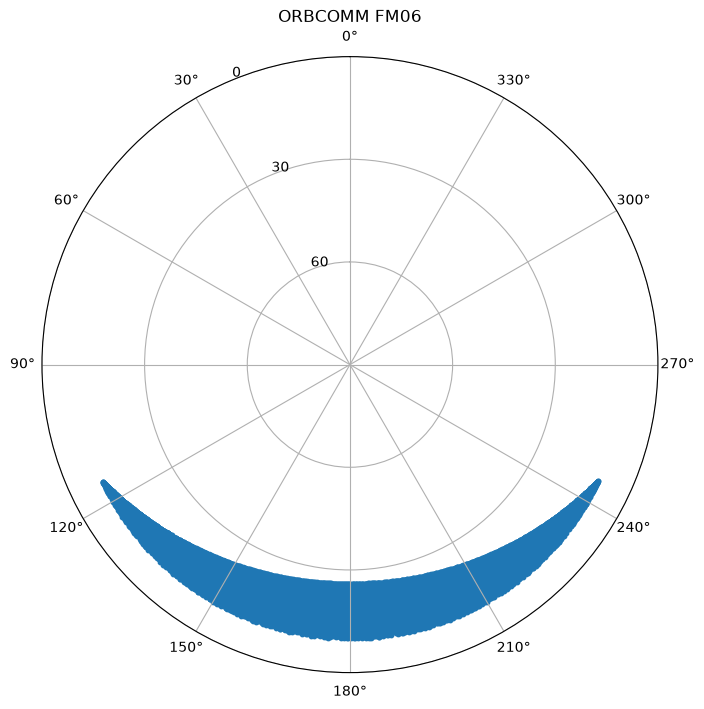

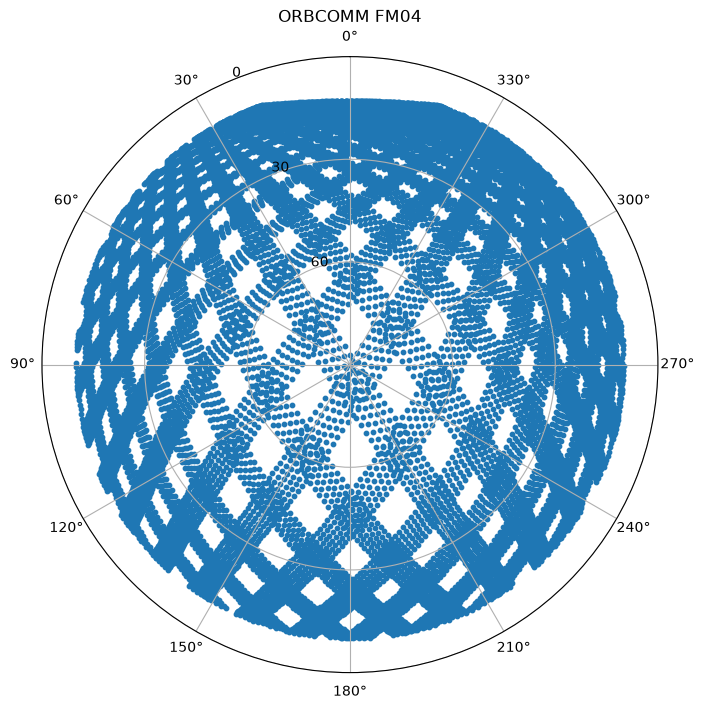

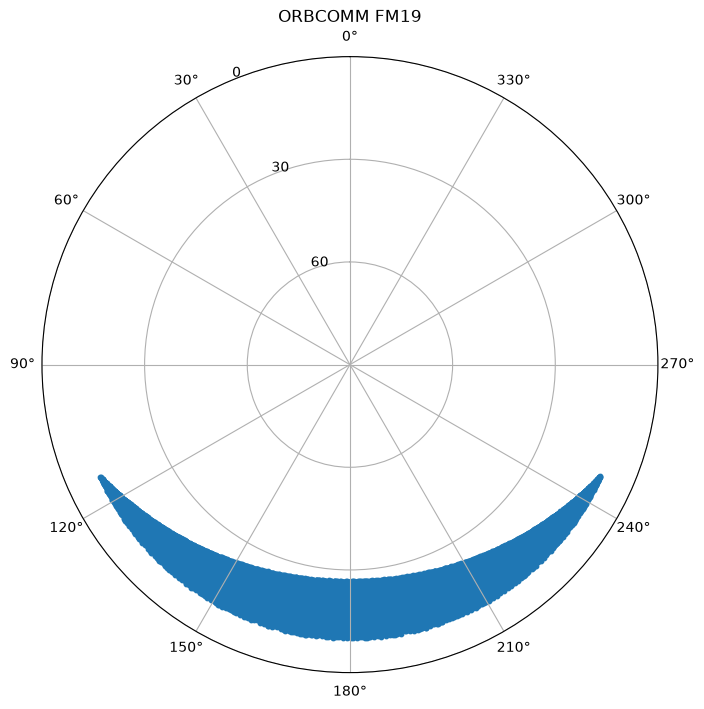

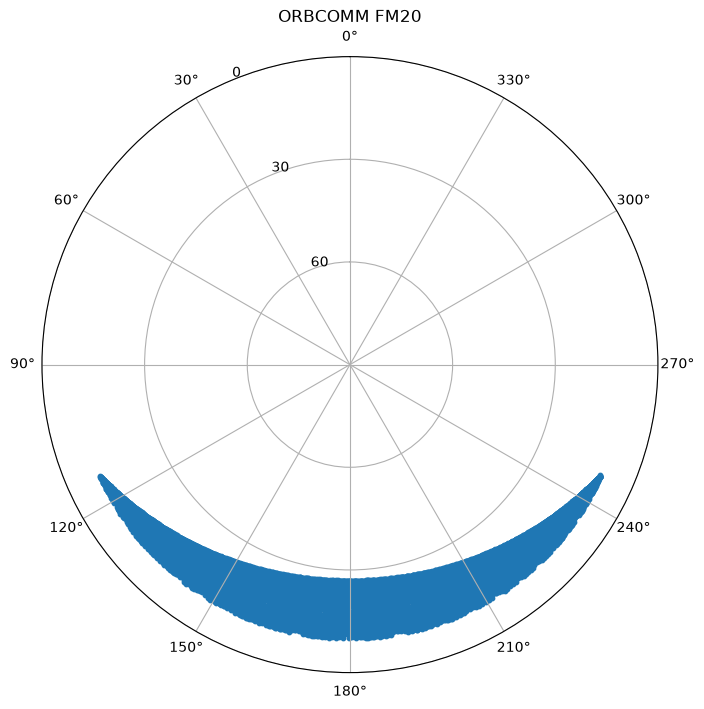

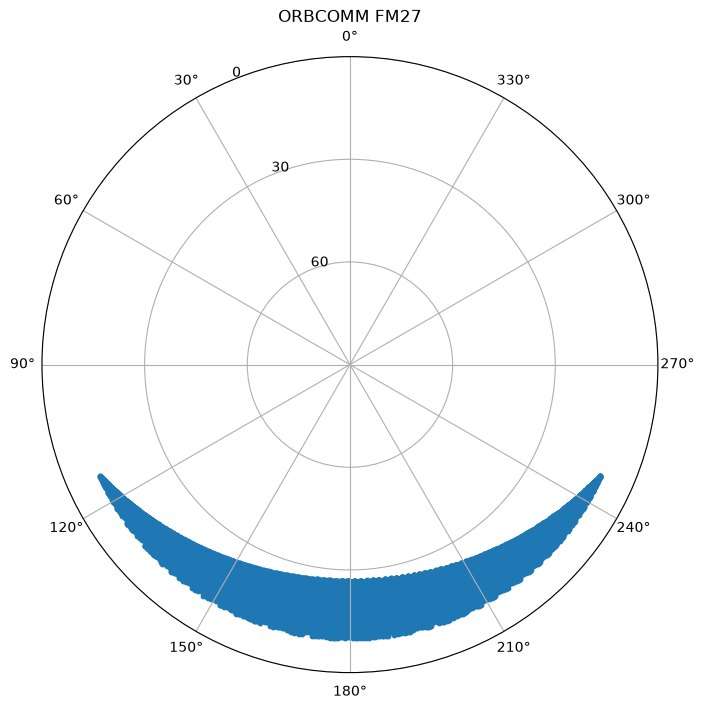

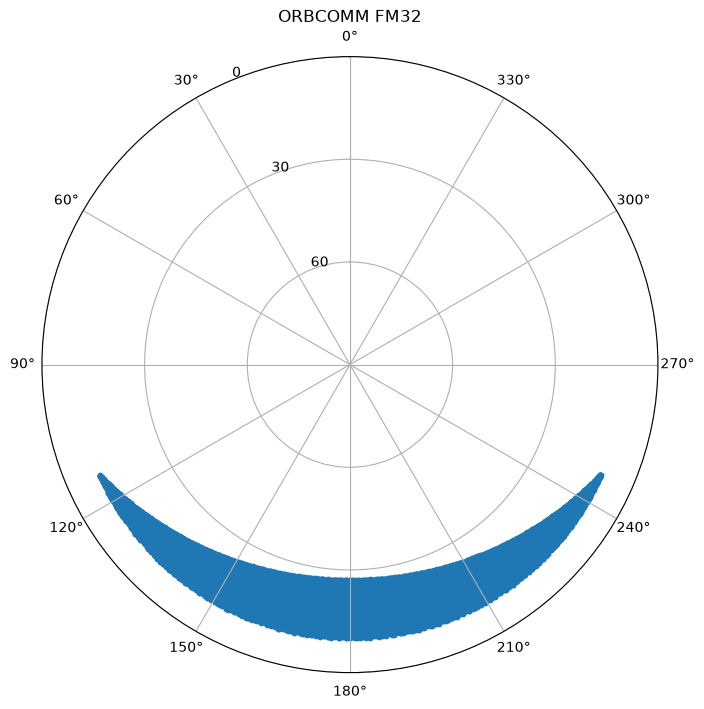

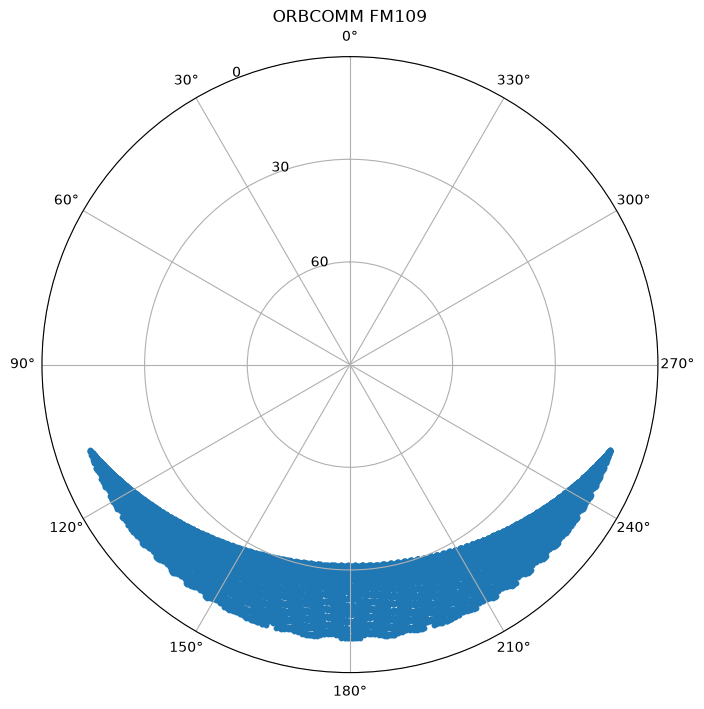

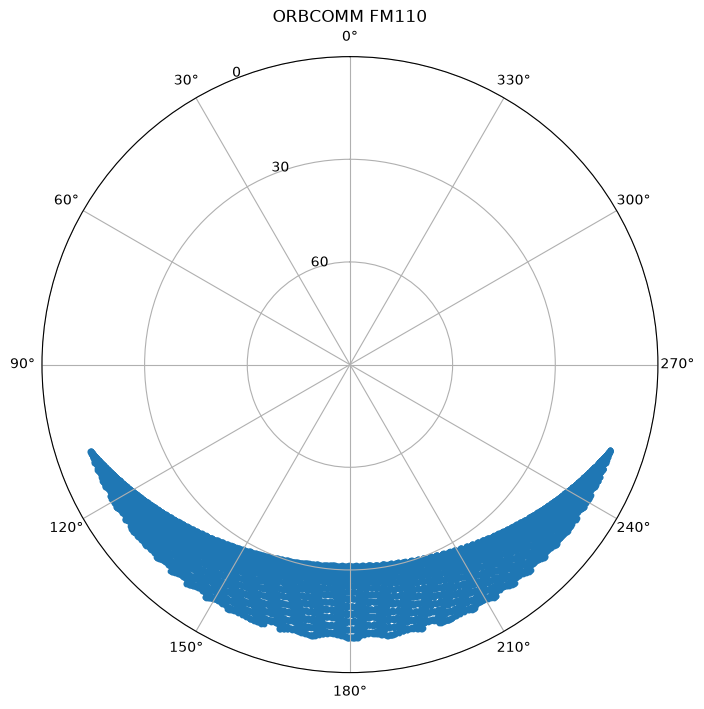

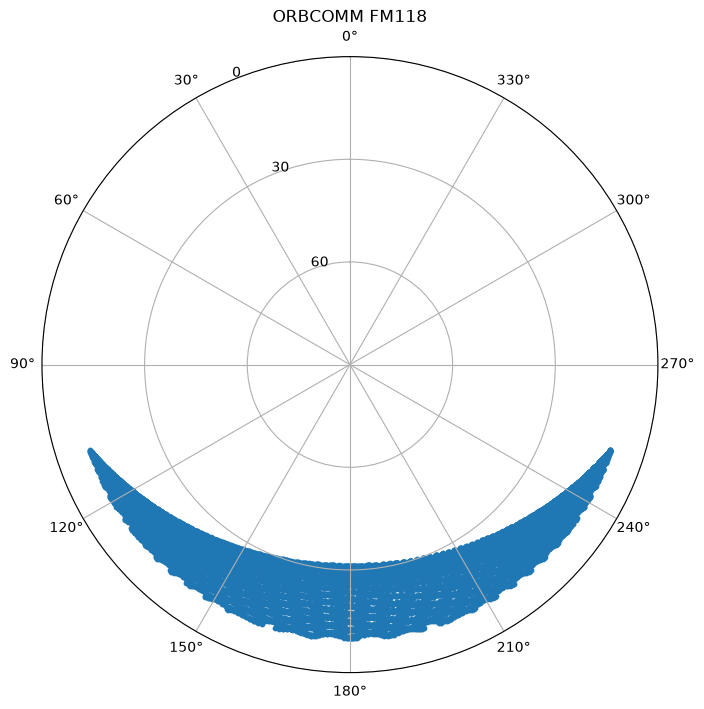

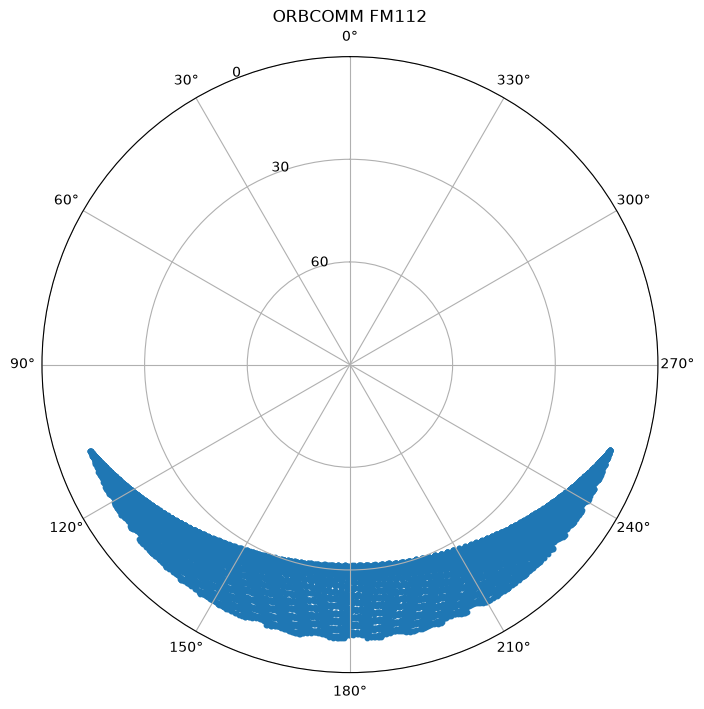

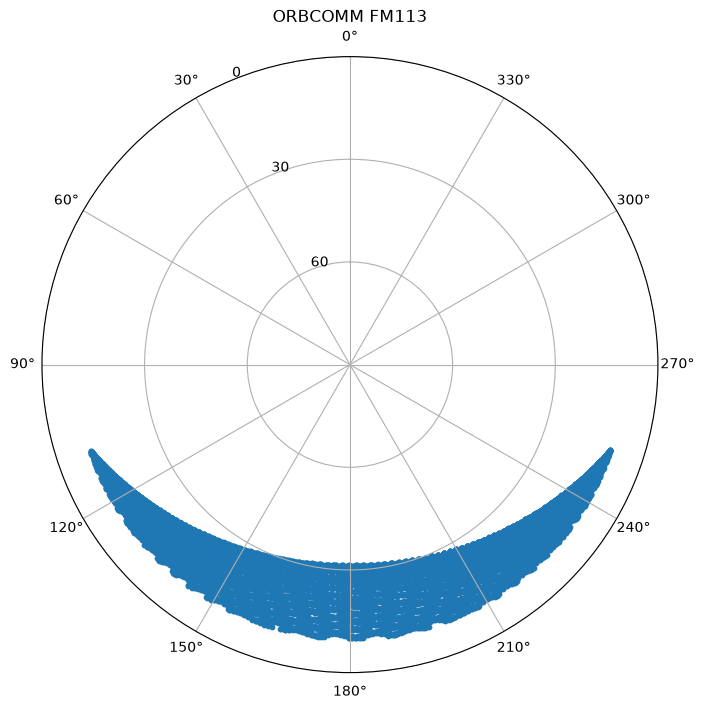

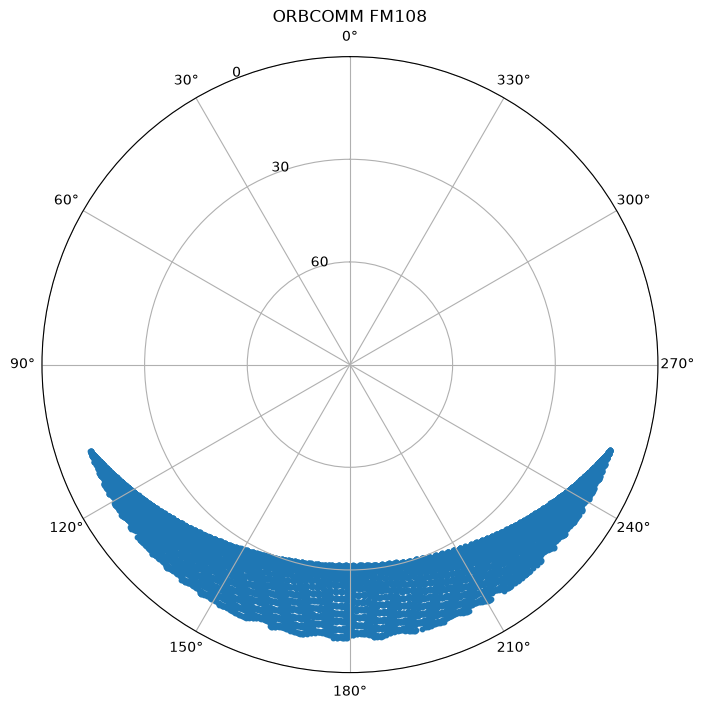

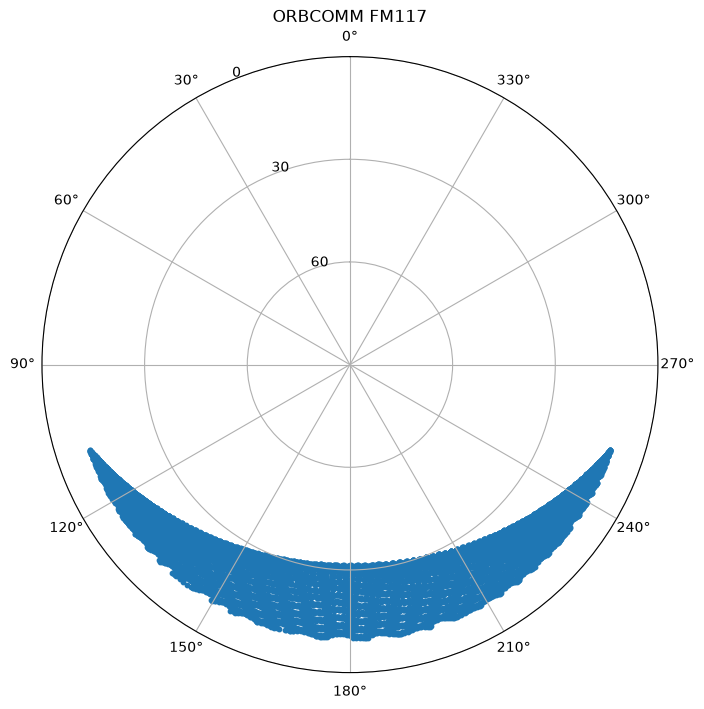

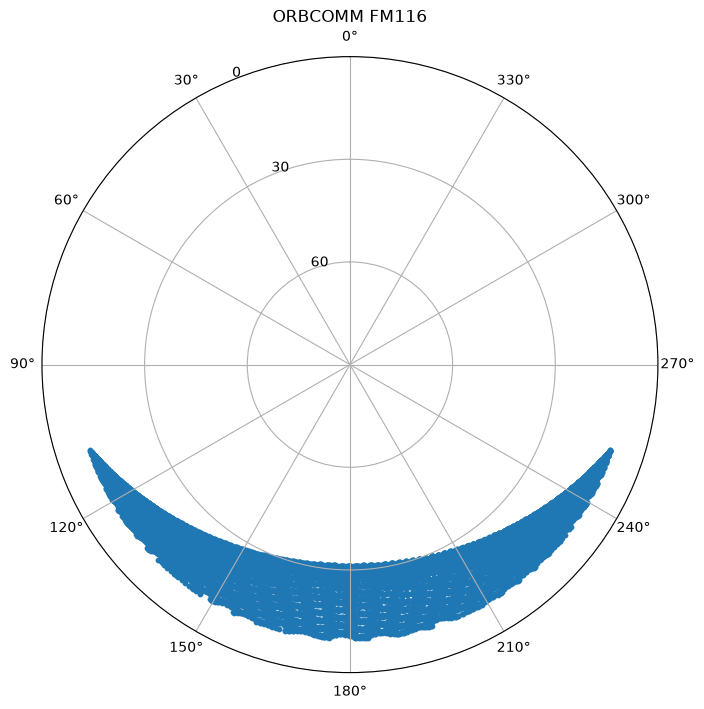

In [ ]:
%matplotlib inline
for satellite in sats:
    plot_satellite(satellite, qth, t0, t1).show()

for satellite in sorted(sats, key=lambda s: s.name):
    print(f"Satellite: {satellite.name}")